# Task 2 — Deep Learning Sentiment Analysis with Recurrent Models

### Introduction
In Phase 4, we built lexicon-based sentiment models. While they work well for simple cases, they fail on complex language patterns like double negation or long-distance dependent modifiers.

In this notebook, we build a **Deep Sequence Sentiment Classifier** in PyTorch. We train this classifier on movie reviews. Instead of treating sentences as bags of words, we feed word embeddings sequentially into an LSTM or GRU cell, allowing the network to build a running representation of contextual sentiment before classifying the sentence.

### Architecture Overview
1.  **Embedding Layer**: Map word integer indices to dense vectors.
2.  **LSTM Layer**: Processes word embeddings sequentially, tracking hidden states ($h_t$).
3.  **Linear Classification Head**: Takes the final hidden state representation ($h_T$) and maps it to a binary label (0 = Negative, 1 = Positive).



### Step 1 — Build Movie Reviews Dataset Pipeline


In [1]:
import re
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt

# A toy review dataset for lightning-fast training validation
reviews = [
    ("i love this movie it is absolutely wonderful and great", 1),
    ("superb acting fantastic plot highly recommended", 1),
    ("a masterpiece of modern cinema beautiful story", 1),
    ("this film is amazing brilliant writing and direction", 1),
    ("loved the characters and the stunning visual effects", 1),
    ("awful waste of time terrible script acting was bad", 0),
    ("boring movie fell asleep halfway through extremely poor", 0),
    ("waste of money bad direction and plot holes everywhere", 0),
    ("worst film i have seen in years absolute garbage", 0),
    ("disappointed with the stupid story and bad characters", 0)
]

# Tokenize and build vocabulary
def clean_text(t):
    return re.findall(r'\b\w+\b', t.lower())

cleaned_reviews = [(clean_text(r[0]), r[1]) for r in reviews]
all_words = []
for words, _ in cleaned_reviews:
    all_words.extend(words)

vocab = sorted(list(set(all_words)))
word_to_ix = {word: idx + 2 for idx, word in enumerate(vocab)}
word_to_ix['<PAD>'] = 0
word_to_ix['<UNK>'] = 1
ix_to_word = {idx: word for word, idx in word_to_ix.items()}

vocab_size = len(word_to_ix)

# Pad sequences to length 10
max_len = 10
X = []
y = []

for words, label in cleaned_reviews:
    indices = [word_to_ix.get(w, 1) for w in words]
    if len(indices) < max_len:
        indices = [0] * (max_len - len(indices)) + indices
    else:
        indices = indices[:max_len]
    X.append(indices)
    y.append(label)

X_tensor = torch.tensor(X, dtype=torch.long)
y_tensor = torch.tensor(y, dtype=torch.float32)

dataset = TensorDataset(X_tensor, y_tensor)
loader = DataLoader(dataset, batch_size=2, shuffle=True)

print(f"Vocabulary size: {vocab_size}")
print(f"Dataset shape: {X_tensor.shape}")



Vocabulary size: 63
Dataset shape: torch.Size([10, 10])


### Step 2 — Define LSTM Classifier Architecture


In [2]:
class SentimentLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim):
        super(SentimentLSTM, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, 1)
        self.sigmoid = nn.Sigmoid()
        
    def forward(self, x):
        embedded = self.embedding(x)
        out, (h, c) = self.lstm(embedded)
        # Grab final hidden state output of the sequence
        last_out = out[:, -1, :]
        logits = self.fc(last_out)
        probs = self.sigmoid(logits)
        return probs.squeeze()

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = SentimentLSTM(vocab_size, embed_dim=16, hidden_dim=16).to(device)
print(model)



SentimentLSTM(
  (embedding): Embedding(63, 16, padding_idx=0)
  (lstm): LSTM(16, 16, batch_first=True)
  (fc): Linear(in_features=16, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)


### Step 3 — Train and Evaluate model


Epoch 10/40 - Train Loss: 0.0181
Epoch 20/40 - Train Loss: 0.0034


Epoch 30/40 - Train Loss: 0.0018
Epoch 40/40 - Train Loss: 0.0012


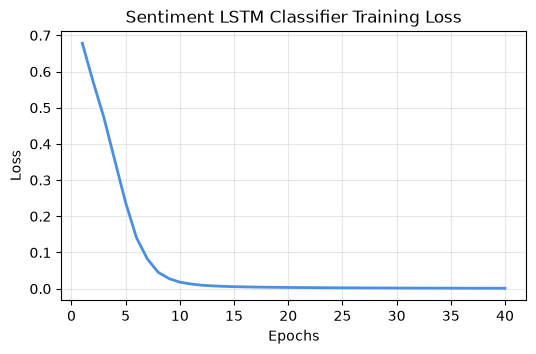


Test Sentence: 'this movie is wonderful plot acting recommended'
Predicted Sentiment Score: 0.9964 (Positive)


In [3]:
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

epochs = 40
losses = []

for epoch in range(epochs):
    model.train()
    total_loss = 0
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        probs = model(X_batch)
        loss = criterion(probs, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    avg_loss = total_loss / len(loader)
    losses.append(avg_loss)
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{epochs} - Train Loss: {avg_loss:.4f}")

# Plot loss curves
plt.figure(figsize=(6, 3.5))
plt.plot(range(1, epochs+1), losses, color='#4A90E2', linewidth=2)
plt.title("Sentiment LSTM Classifier Training Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.grid(True, alpha=0.3)
plt.show()

# Quick test evaluation
model.eval()
test_sentence = "this movie is wonderful plot acting recommended"
test_cleaned = clean_text(test_sentence)
test_indices = [word_to_ix.get(w, 1) for w in test_cleaned]
test_indices = [0] * (max_len - len(test_indices)) + test_indices
test_tensor = torch.tensor([test_indices], dtype=torch.long).to(device)

with torch.no_grad():
    score = model(test_tensor).item()
print(f"\nTest Sentence: '{test_sentence}'")
print(f"Predicted Sentiment Score: {score:.4f} ({'Positive' if score > 0.5 else 'Negative'})")



### Step 4 — Interactive Sentiment Classification Interface
Type a review below to test the trained LSTM model's sentiment prediction!


In [4]:
import ipywidgets as widgets
from IPython.display import display, HTML, clear_output

input_review = widgets.Text(
    value="This movie was fantastic and absolutely wonderful!",
    placeholder="Type a review here...",
    description="Review:",
    layout=widgets.Layout(width="70%")
)

classify_btn = widgets.Button(
    description="Classify Sentiment",
    button_style="info",
    icon="check",
    layout=widgets.Layout(width="20%")
)

output_area = widgets.Output()

def on_classify(b):
    with output_area:
        clear_output()
        text = input_review.value.strip()
        if not text:
            print("Please enter a review.")
            return
            
        model.eval()
        tokens = clean_text(text)
        indices = [word_to_ix.get(w, 1) for w in tokens]
        if len(indices) < max_len:
            indices = [0] * (max_len - len(indices)) + indices
        else:
            indices = indices[:max_len]
            
        test_tensor = torch.tensor([indices], dtype=torch.long).to(device)
        with torch.no_grad():
            score = model(test_tensor).item()
            
        sentiment = "POSITIVE" if score > 0.5 else "NEGATIVE"
        color = "#2ECC71" if score > 0.5 else "#E74C3C"
        
        # Display results with HTML styling
        display(HTML(f'''
        <div style="padding: 10px; border-radius: 5px; background-color: {color}; color: white; font-weight: bold; width: 60%; text-align: center;">
            Predicted Sentiment: {sentiment} ({score*100:.2f}% Confidence)
        </div>
        '''))

classify_btn.on_click(on_classify)

ui = widgets.VBox([
    widgets.HTML("<h3>Interactive Sentiment Classifier</h3>"),
    widgets.HBox([input_review, classify_btn]),
    output_area
])
display(ui)
on_classify(None)

